# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import missingno as msno 

import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

In [2]:
df= pd.read_excel('new_data_set.xlsx')
df.head()

,pid,facilityid,examinationdate,age,sex,ee_zn_myasthener_exazerbation,zn_myasthener_krise,age_erst,age_diag,time_erst_to_diag,...,japan_classification,ee_postinterventionstatus_rb,eomg_lomg_45,eomg_lomg_50,thymom,adl_pass,qmg_pass,qol_pass,ee_auswahlbildungsabschluss_rb,schwerbehinderung
0,00QM6V52,2019009,2023-01-31 00:00:00,34.961111,0,0.0,1,17.583333,17.750000,0.166667,...,1.0,5.0,0.0,0.0,0.0,1.0,1.0,NaN,1.0,2.0
1,06U8DLMD,2019006,2023-01-31 00:00:00,59.711111,1,0.0,0,55.750000,58.916667,3.166667,...,4.0,6.0,1.0,1.0,0.0,NaN,1.0,NaN,1.0,0.0
2,0D31R9UX,2019010,2023-07-19 00:00:00,83.344444,1,1.0,0,80.666667,80.916667,0.250000,...,4.0,7.0,1.0,1.0,0.0,0.0,1.0,1.0,4.0,2.0
3,0DAJN5Y2,2019019,2023-01-17 00:00:00,56.505556,1,0.0,0,56.166667,56.250000,0.083333,...,4.0,6.0,1.0,1.0,0.0,NaN,1.0,NaN,0.0,0.0
4,0G1WYG21,2019004,2020-12-10 00:00:00,39.986111,0,NaN,0,21.083333,21.083333,0.000000,...,4.0,2.0,0.0,0.0,0.0,1.0,NaN,0.0,2.0,0.0


In [3]:
rename_cols = {
    'facilityid': 'facilityid',
    'age': 'age',
    'sex': 'sex',
    'time_erst_to_diag': 'first_time_diagnosis',
    'mgfaklassifikation_schlimmste_historisch': 'mgfa_worst_history',
    'dekrement_testergebnis': 'decrement_test_result',
    'ee_autoimmunerkrankungen_rbzu': 'autoimmune_diseases',
    'ee_thymektomie_gr': 'thymectomy_status',
    'kortison_aktuell': 'cortisone_current',
    'azathioprin_aktuell': 'azathioprine_current',
    'mycophenolatmofetil_aktuell': 'mycophenolate_current',
    'methotrexatfolsauure_aktuell': 'methotrexate_folicacid_current',
    'rituximab_aktuell': 'rituximab_current',
    'scoreqmg_neu': 'qmg_score',
    'chronicfatigue_neu': 'chronicfatigue_score',
    'scoreqol_neu': 'qol_score',
    'scoreadl_neu': 'adl_score',
    'aktueller_mgfa_score': 'mgfa_score',
    'seronegative': 'seronegative'
}
df_original = df[list(rename_cols.keys())].rename(columns=rename_cols)
df_original.head()

,facilityid,age,sex,first_time_diagnosis,mgfa_worst_history,decrement_test_result,autoimmune_diseases,thymectomy_status,cortisone_current,azathioprine_current,mycophenolate_current,methotrexate_folicacid_current,rituximab_current,qmg_score,chronicfatigue_score,qol_score,adl_score,mgfa_score,seronegative
0,2019009,34.961111,0,0.166667,8.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.0,NaN,NaN,2.0,3.0,0.0
1,2019006,59.711111,1,3.166667,2.0,1.0,NaN,0.0,0.0,0.0,1.0,0.0,0,1.0,NaN,NaN,NaN,2.0,0.0
2,2019010,83.344444,1,0.250000,5.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,5.0,12.0,7.0,3.0,2.0,0.0
3,2019019,56.505556,1,0.083333,2.0,NaN,NaN,0.0,1.0,1.0,0.0,0.0,0,4.0,8.0,NaN,NaN,2.0,0.0
4,2019004,39.986111,0,0.000000,5.0,NaN,1.0,0.0,NaN,NaN,NaN,NaN,0,NaN,NaN,10.0,1.0,3.0,0.0


<Axes: >

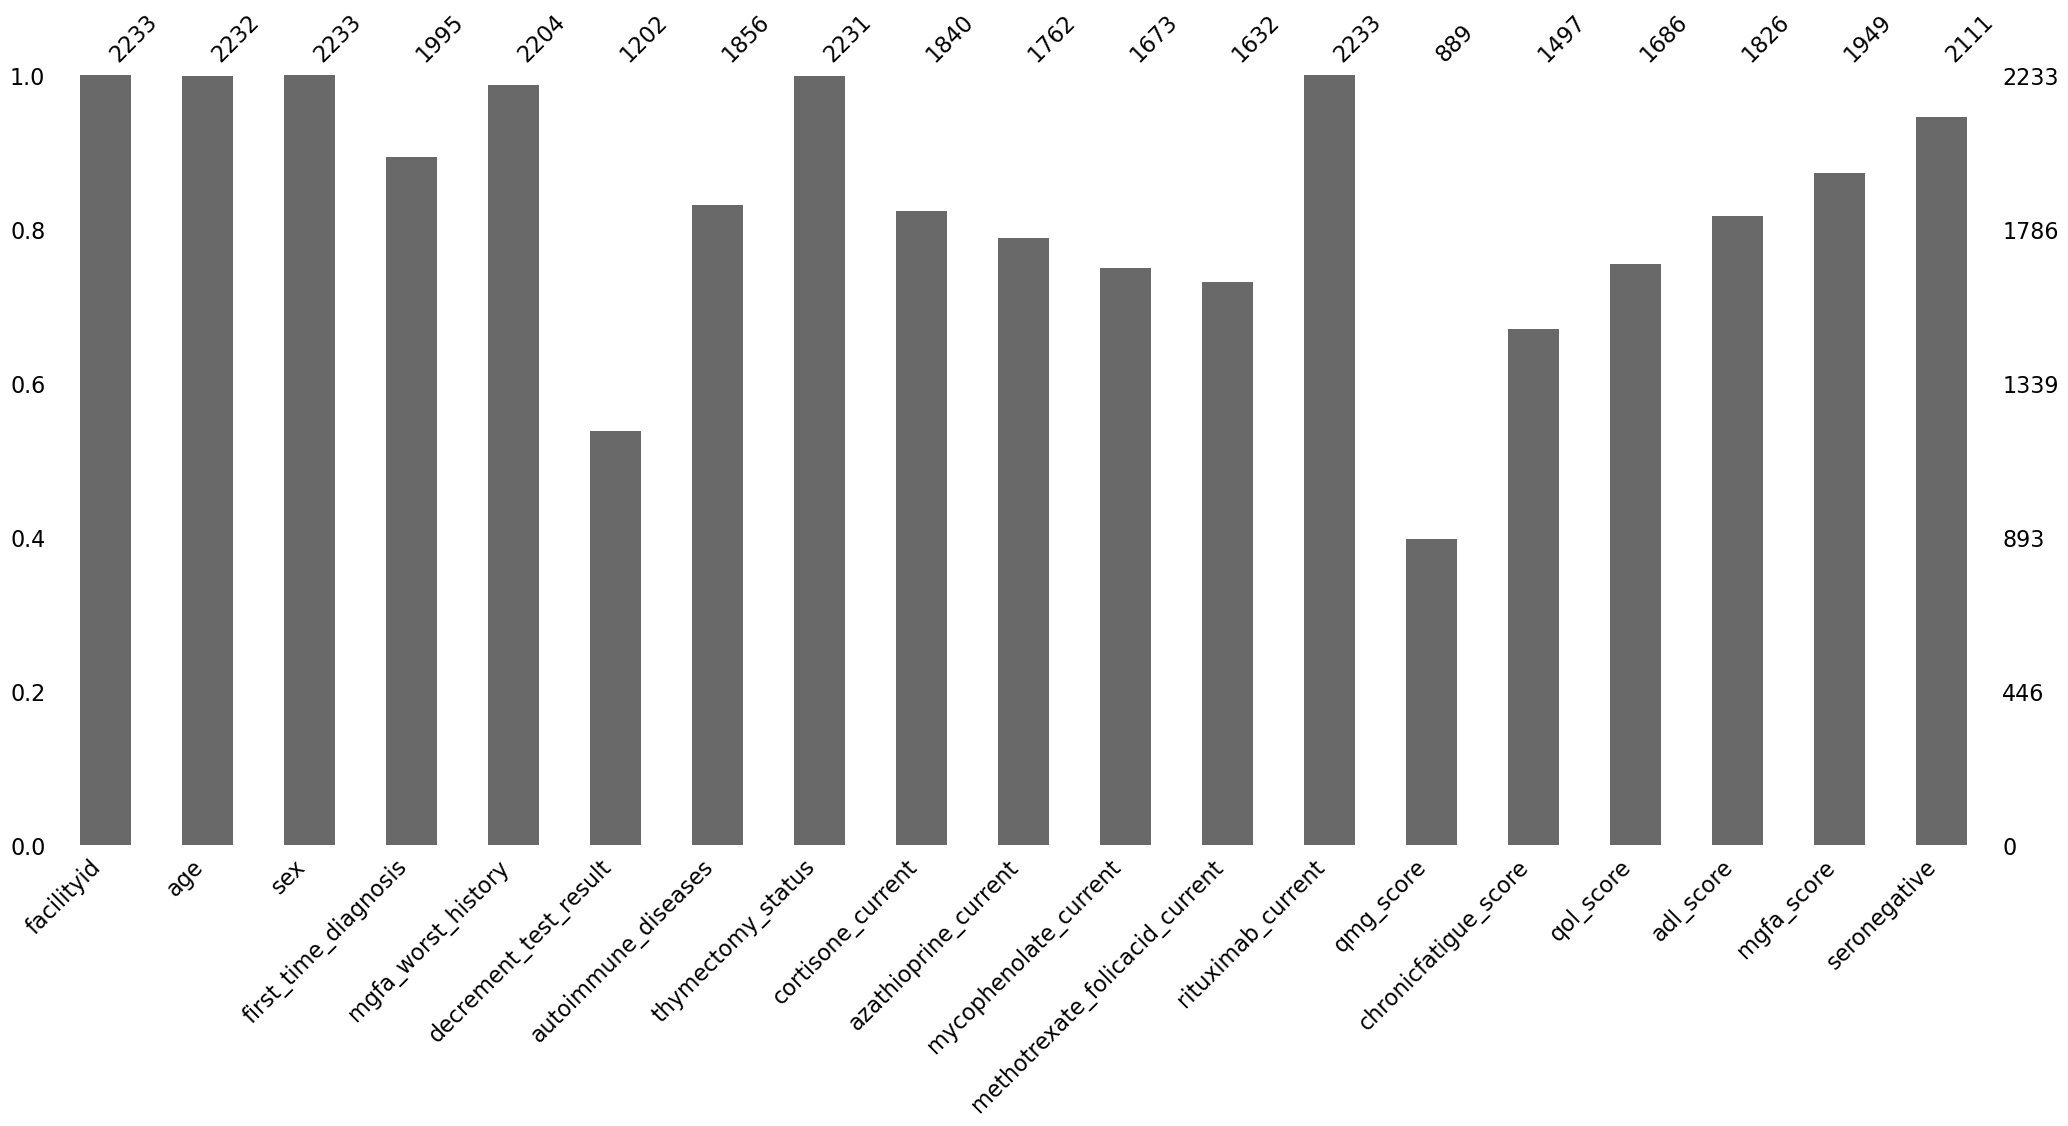

In [4]:
msno.bar(df_original)

<Axes: >

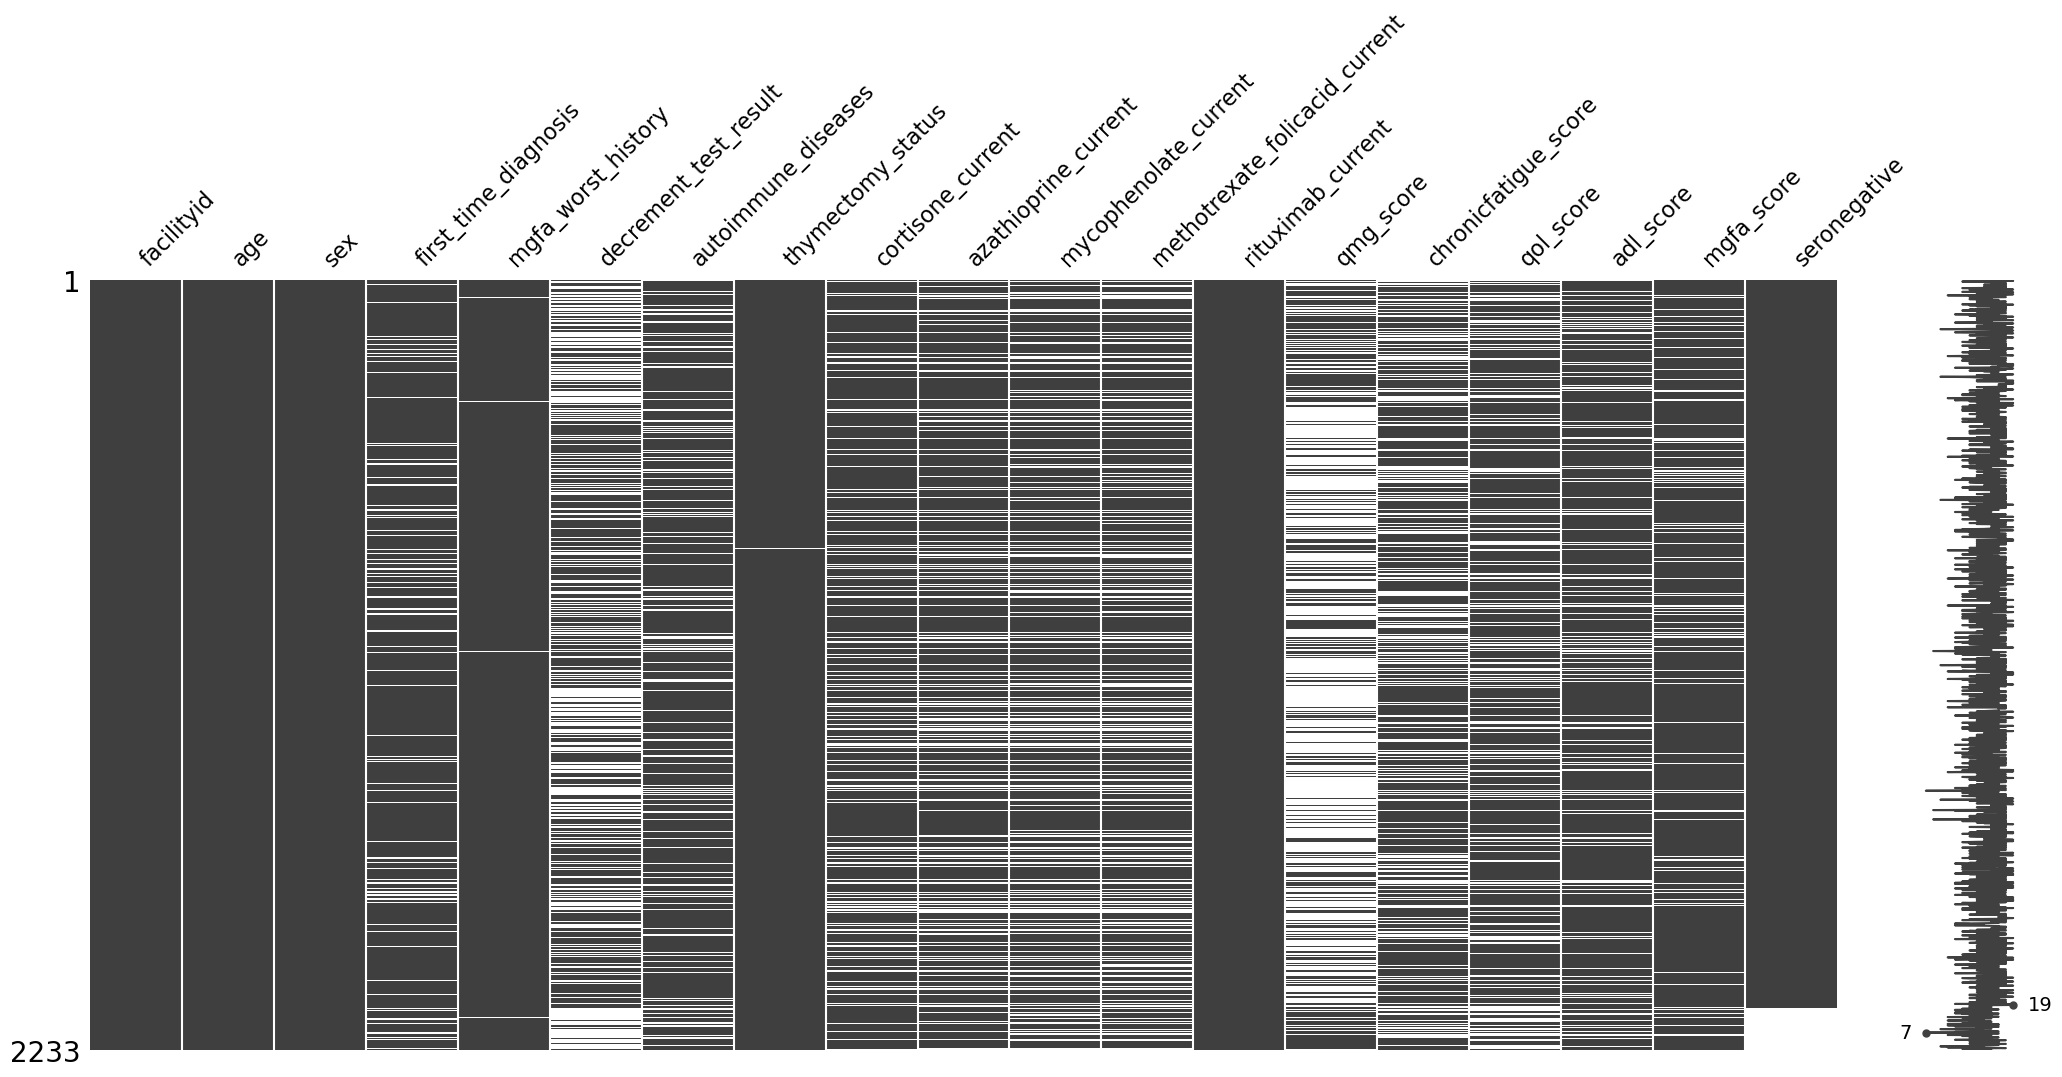

In [5]:
msno.matrix(df_original)

# Sorting Data

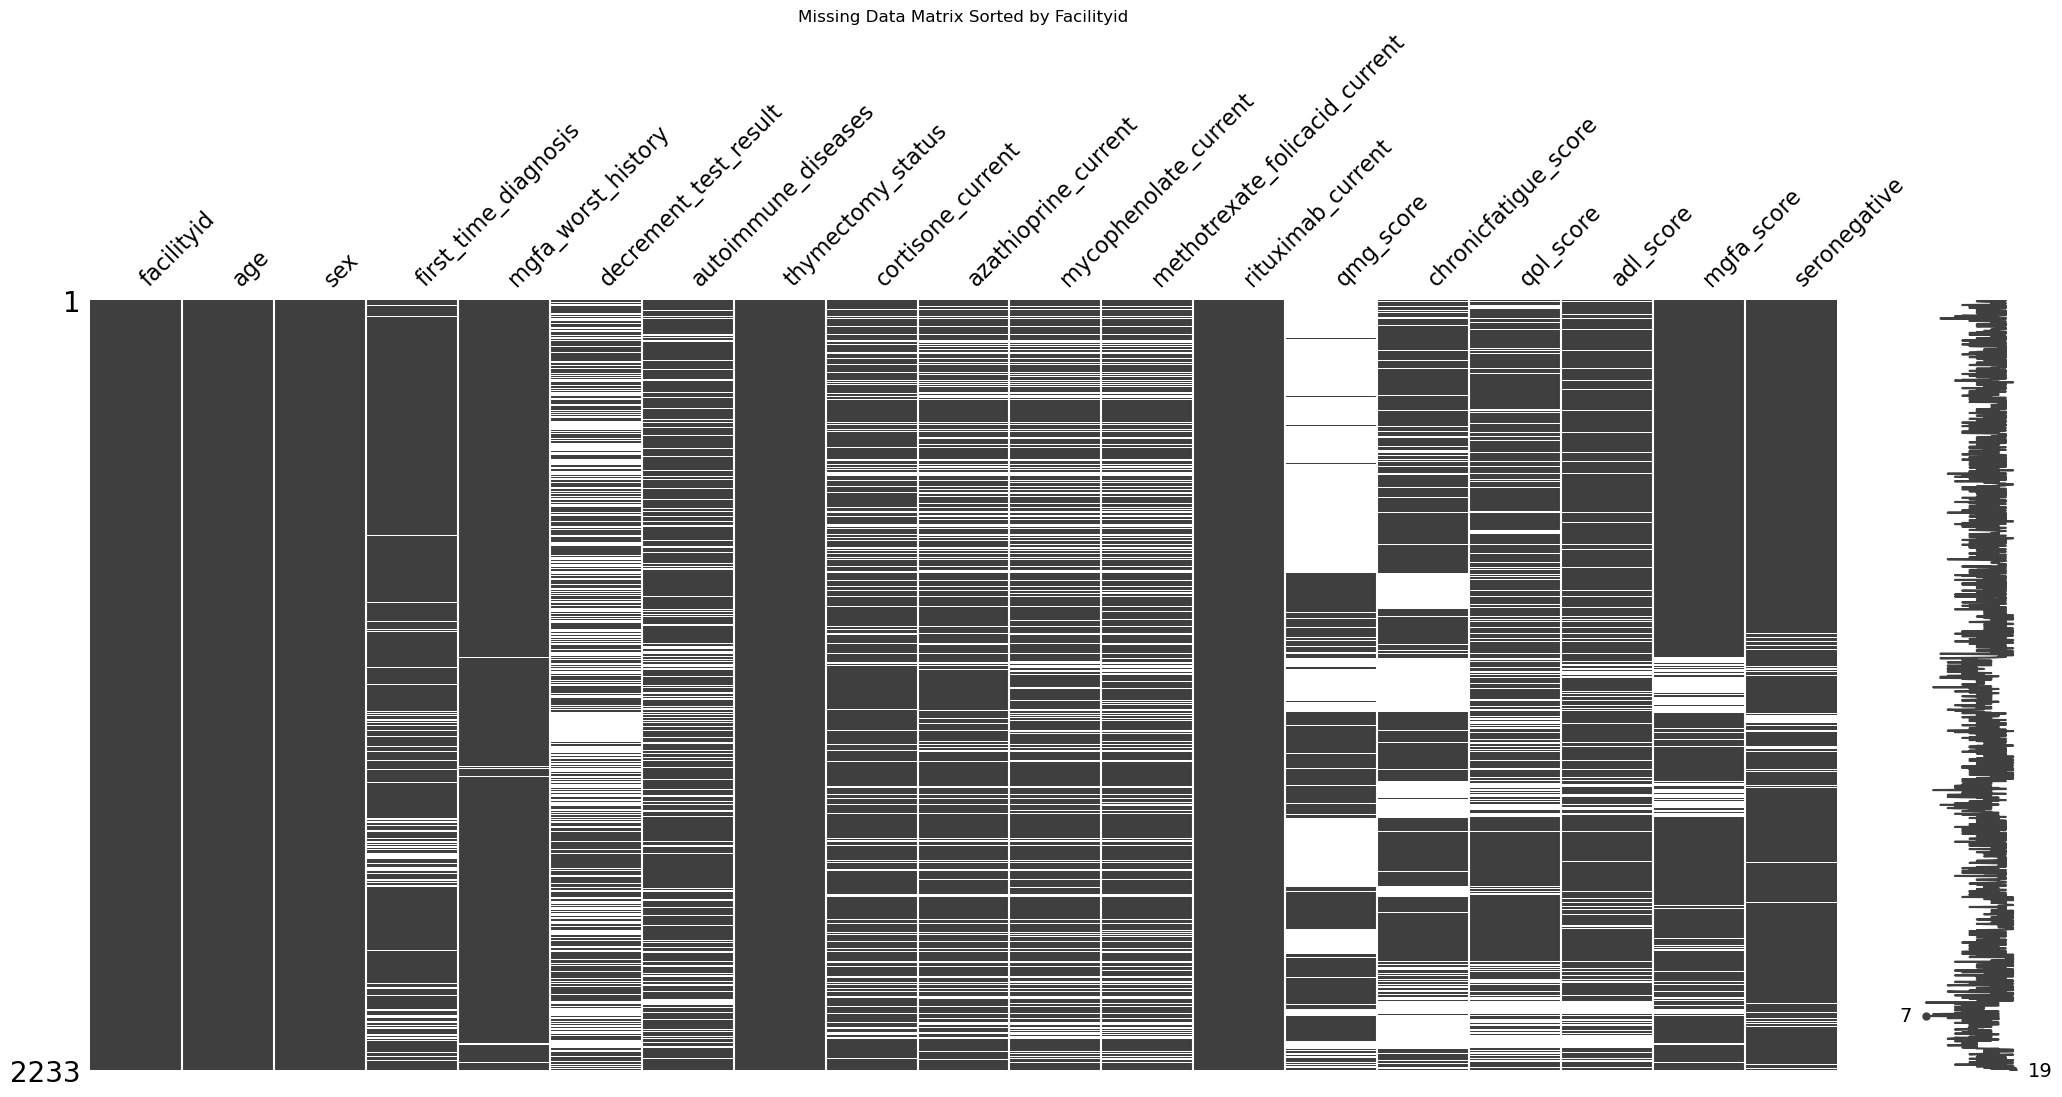

In [6]:
df_facilityid= df_original.sort_values (by=['facilityid'])
msno.matrix(df_facilityid)
plt.title("Missing Data Matrix Sorted by Facilityid")
plt.show()

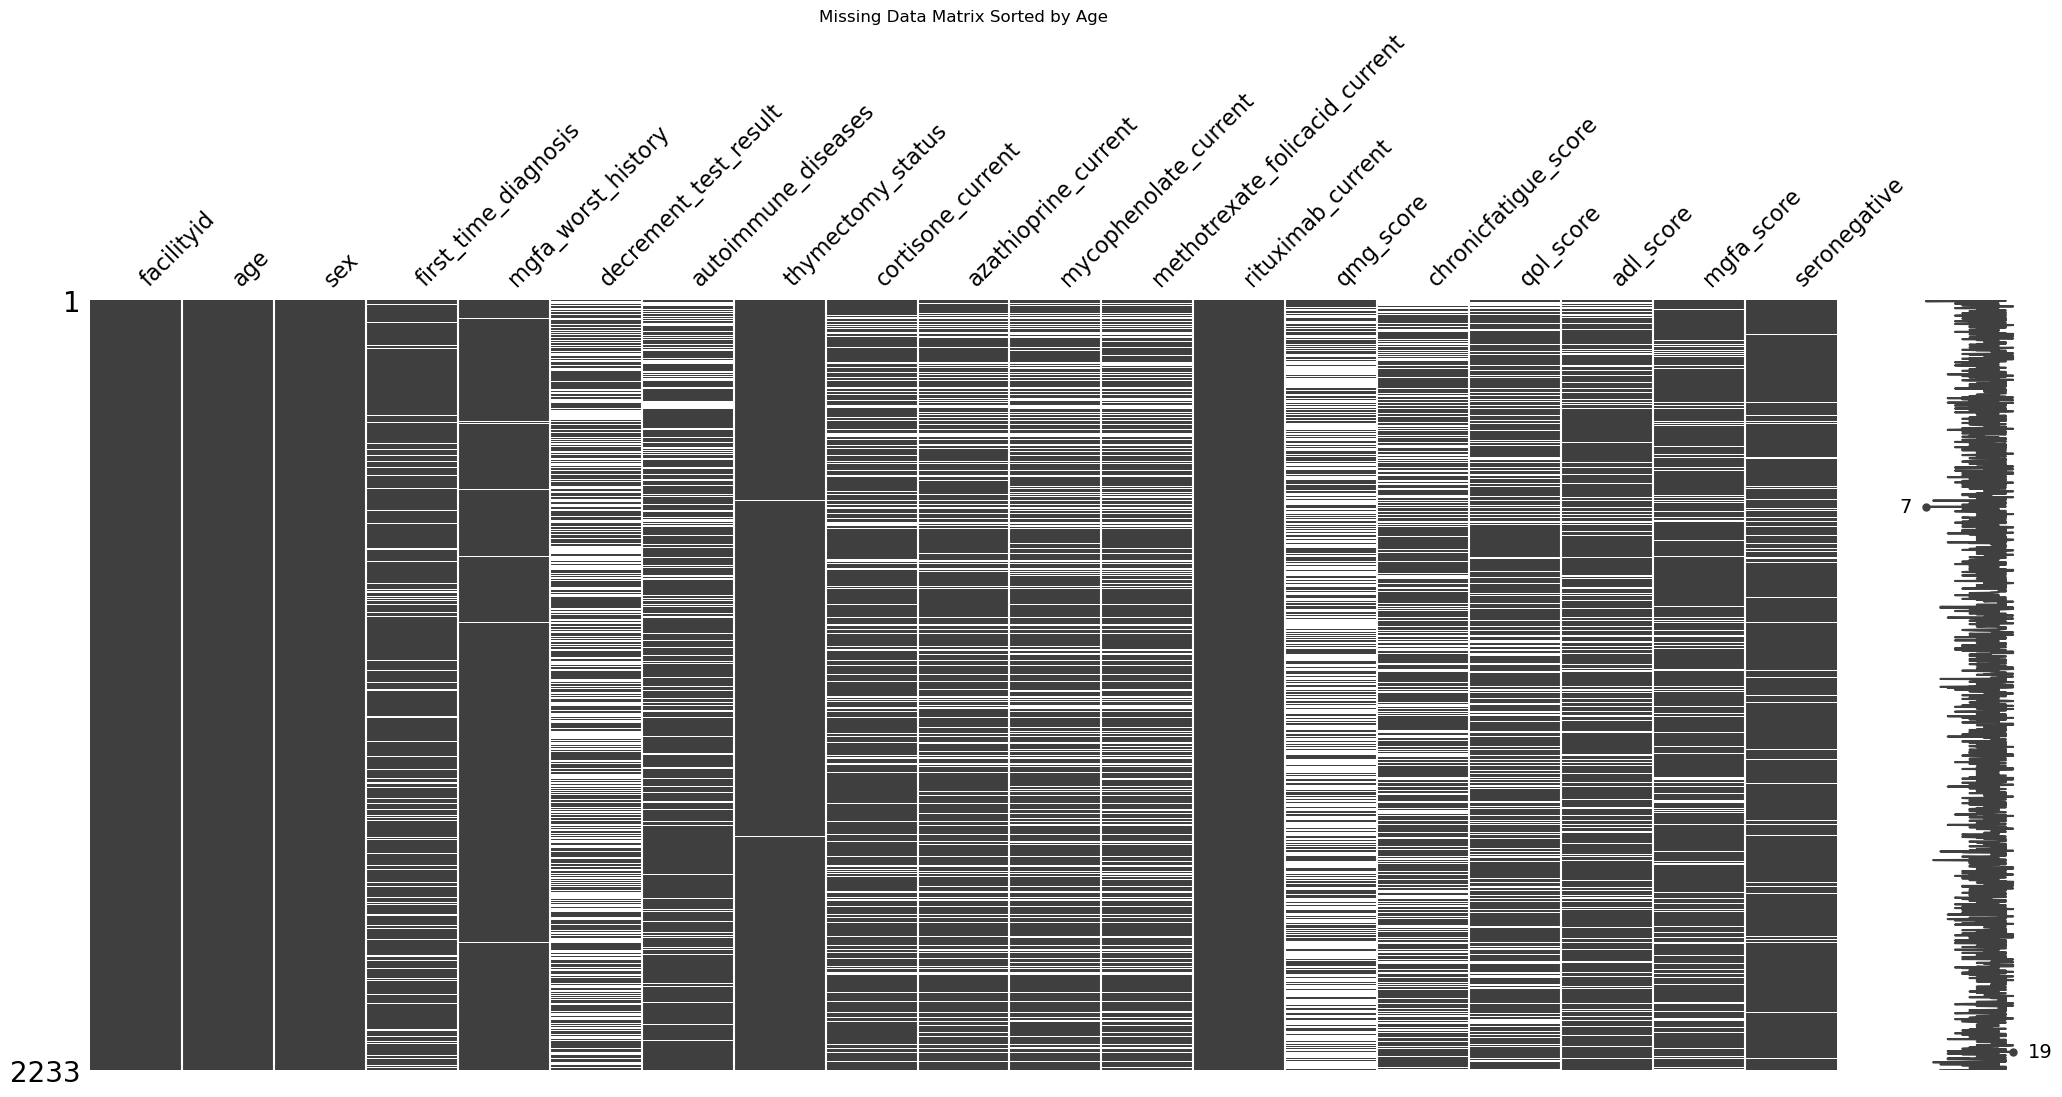

In [7]:
df_age= df_original.sort_values (by=['age'])
msno.matrix(df_age)
plt.title("Missing Data Matrix Sorted by Age")
plt.show()

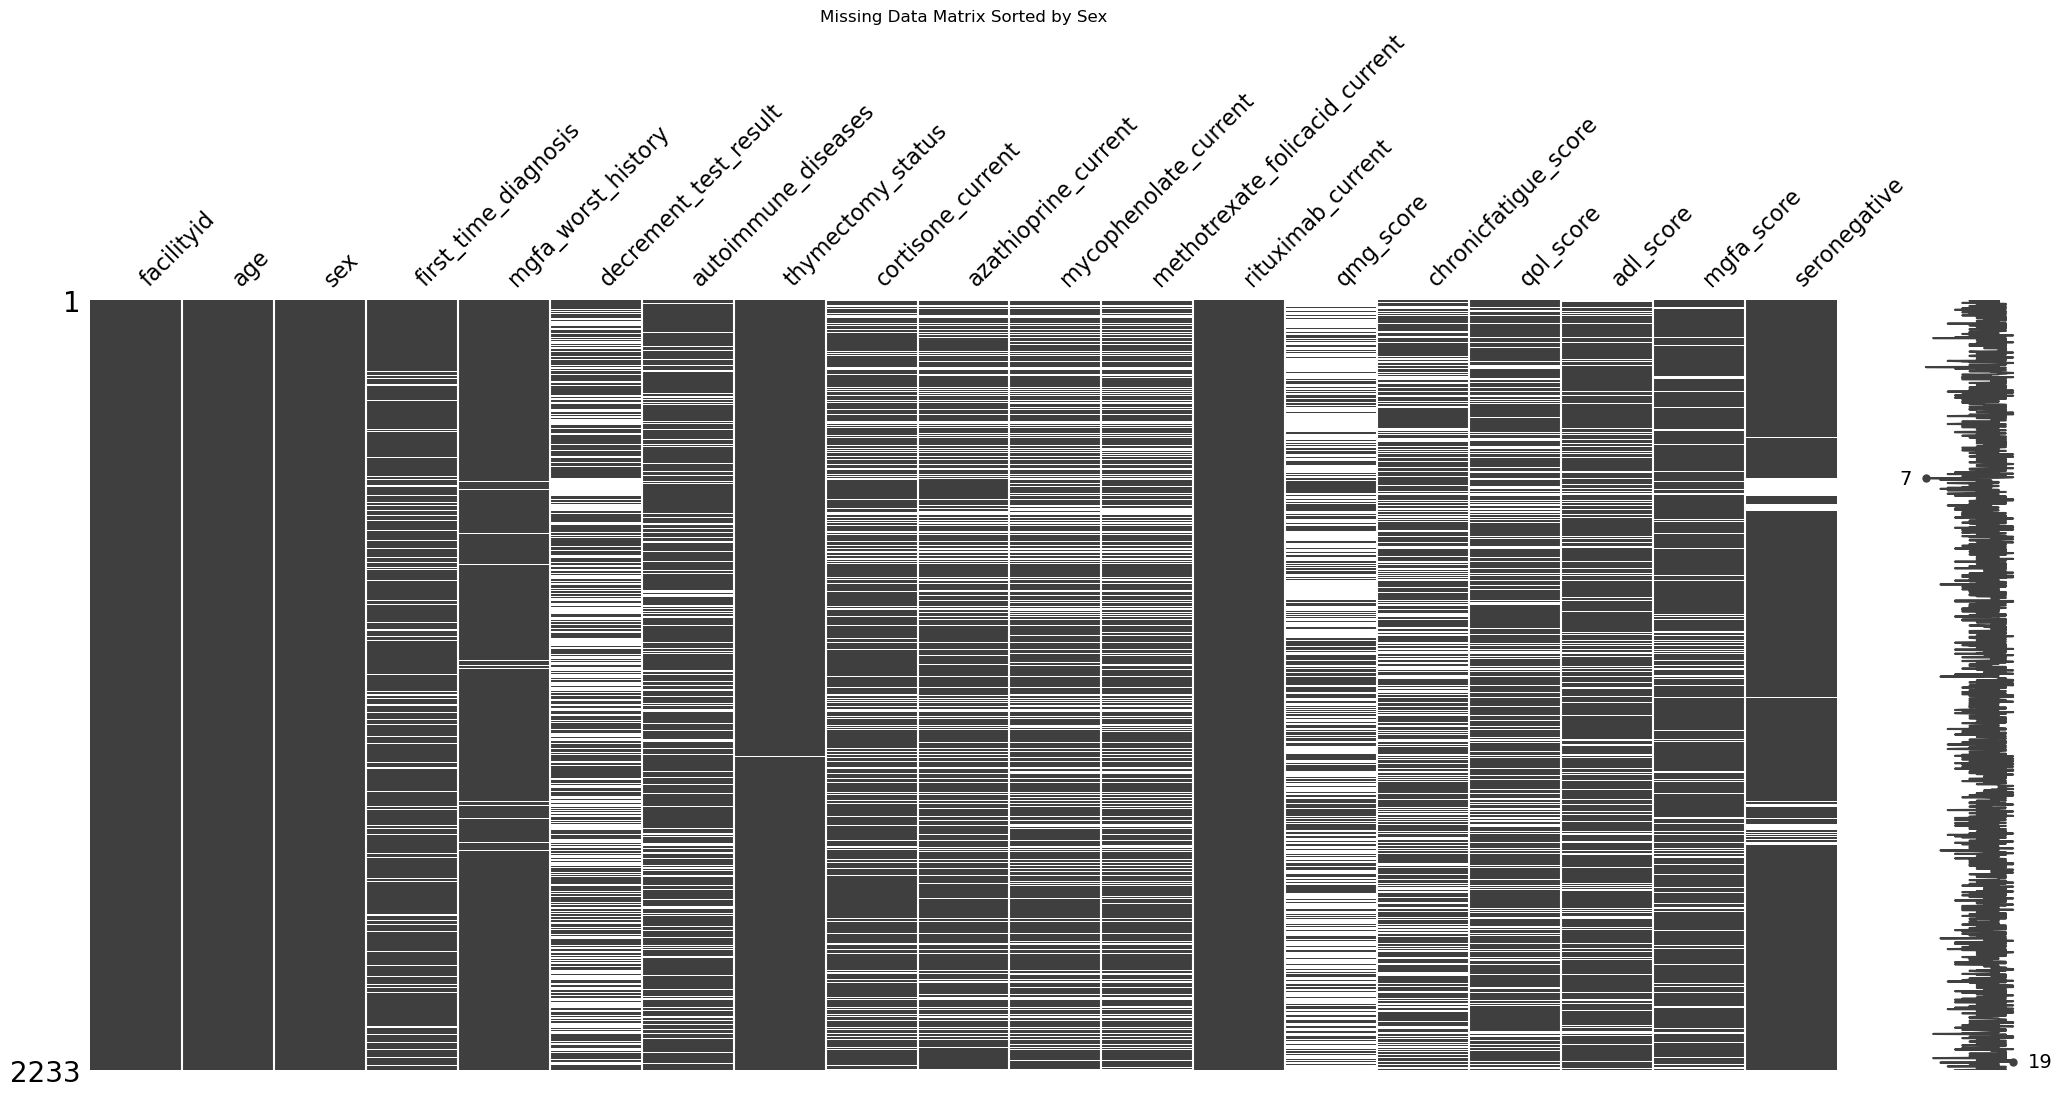

In [8]:
df_sex= df_original.sort_values (by=['sex'])
msno.matrix(df_sex)
plt.title("Missing Data Matrix Sorted by Sex")
plt.show()

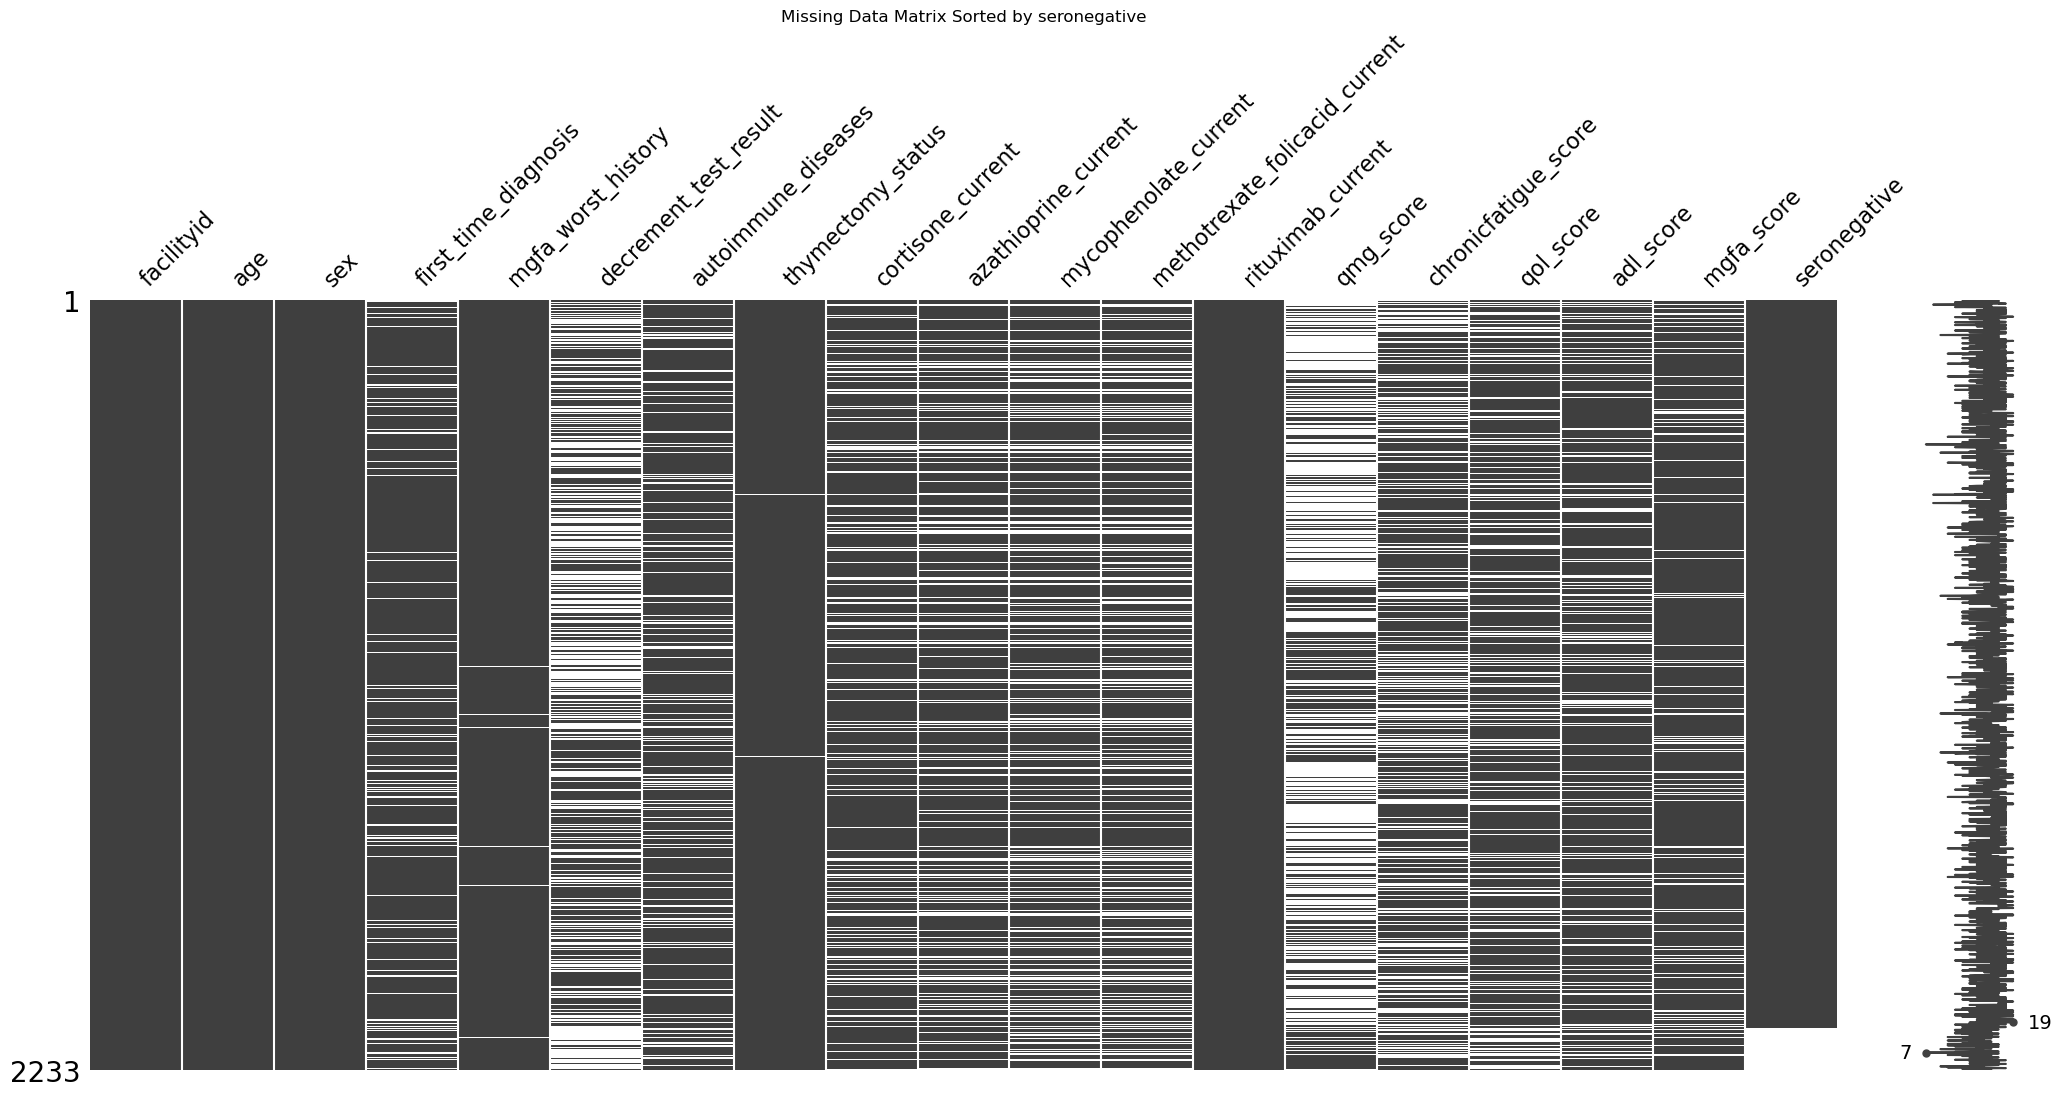

In [9]:
df_seronegative= df_original.sort_values (by=['seronegative'])
msno.matrix(df_seronegative)
plt.title("Missing Data Matrix Sorted by seronegative")
plt.show()

# Sorting Data based on facility ID

In [10]:
df_original['facilityid'].value_counts()

facilityid
2019001    791
2019008    197
2019004    159
2019003    142
2019006    113
2019007    106
2019002    104
2019010     93
2019005     86
2019011     73
2019016     71
2019012     69
2019013     62
2019019     46
2019009     33
2019014     27
2019017     22
2019015     22
2019020     11
2019021      6
Name: count, dtype: int64

<Figure size 1400x800 with 0 Axes>

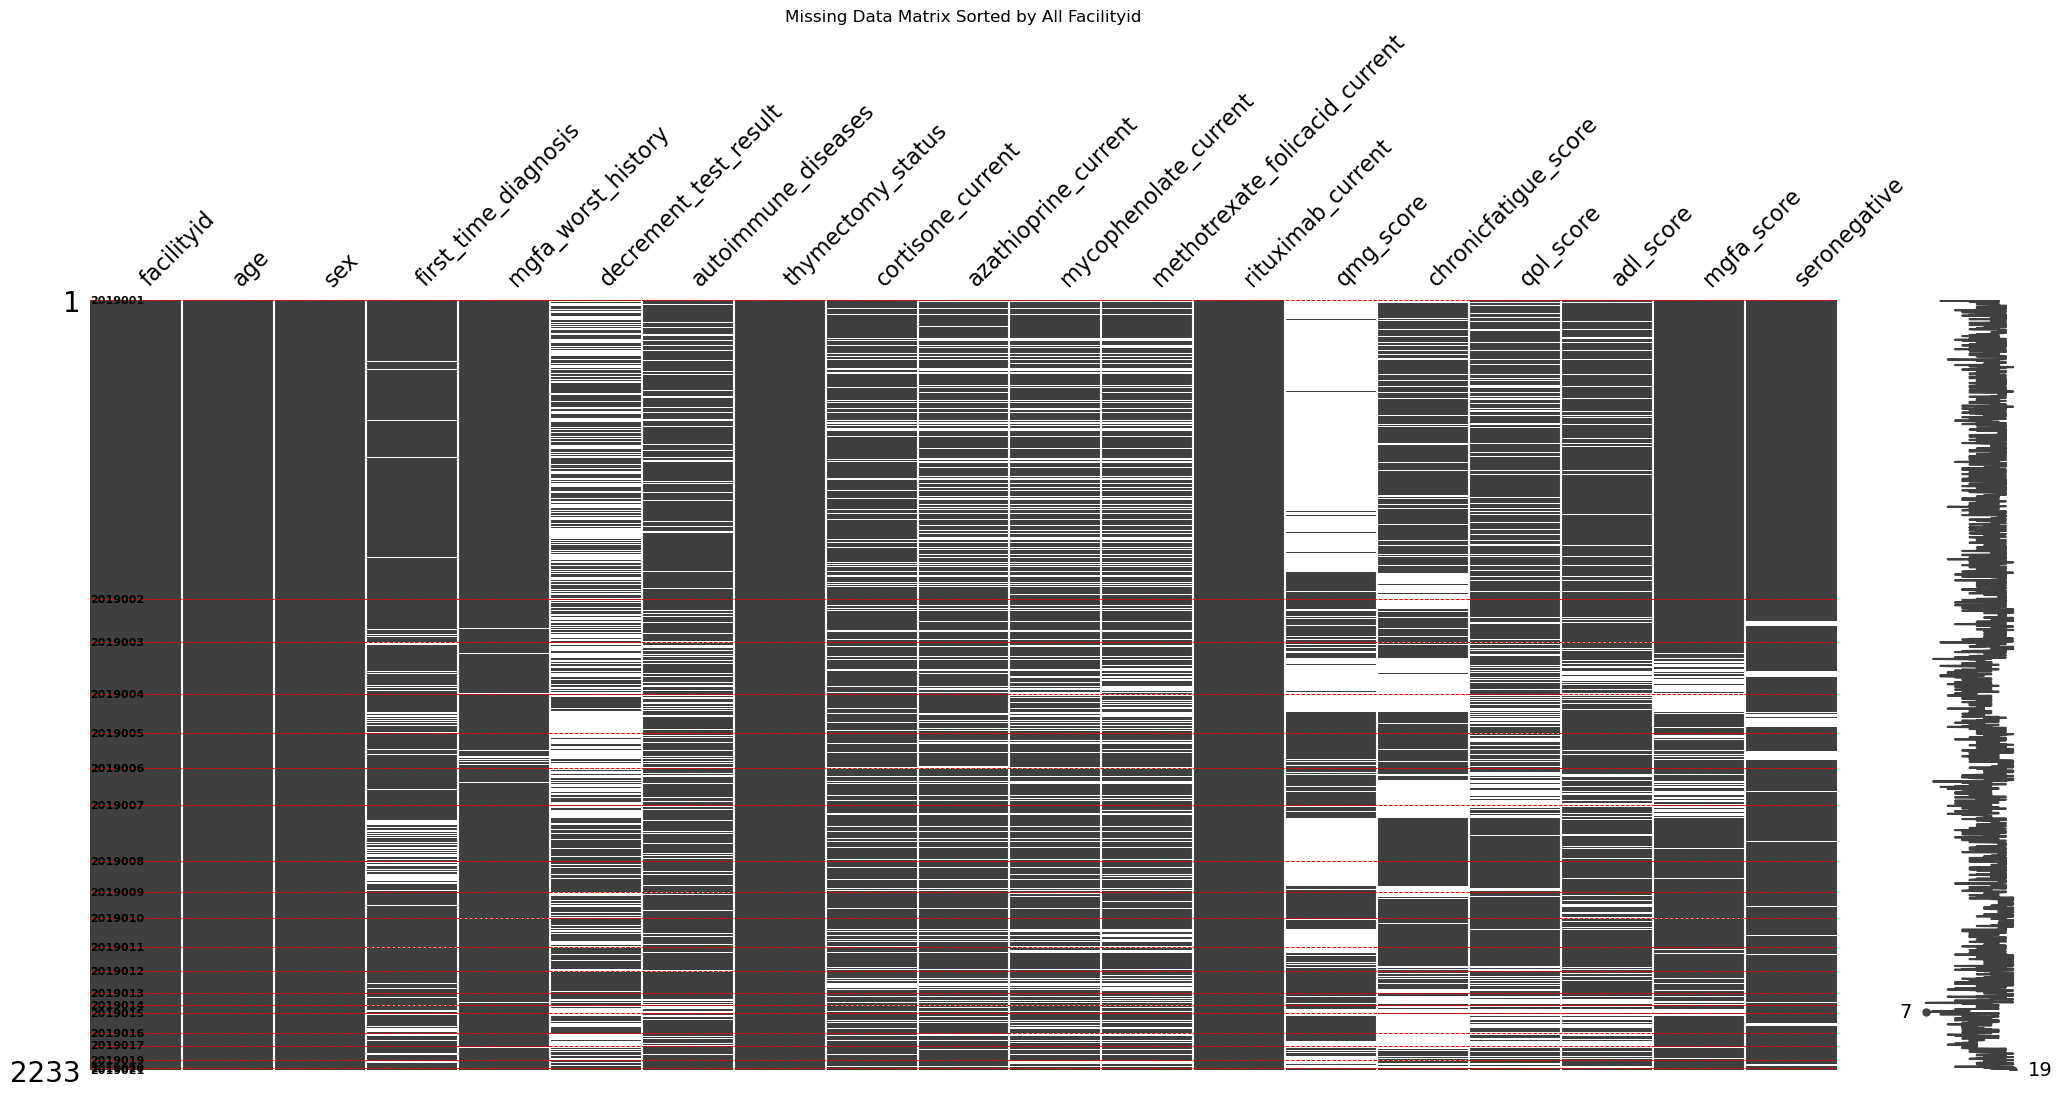

In [11]:
all_facility_ids = [2019001, 2019002, 2019003, 2019004, 2019005, 2019006, 2019007, 
                    2019008, 2019009, 2019010, 2019011, 2019012, 2019013, 2019014, 
                    2019015, 2019016, 2019017, 2019019, 2019020, 2019021]

df_facility_ids = pd.DataFrame({'facilityid': all_facility_ids})

# Merge with the original dataset
df_merged = df_facility_ids.merge(df_original, on='facilityid', how='left')

# Sort the merged data by 'facilityid' in ascending order
df_sorted = df_merged.sort_values(by='facilityid')

plt.figure(figsize=(14, 8))

# Plot the missing data matrix
msno.matrix(df_sorted)

# Get the first occurrence indices of each unique 'facilityid'
facility_indices = [df_sorted[df_sorted['facilityid'] == facility].index[0] for facility in all_facility_ids]

# Plot horizontal lines and mark new facilityid occurrences
for idx in facility_indices:
    plt.axhline(y=idx, color='red', linestyle='--', linewidth=0.7)
    plt.text(-0.5, idx, df_sorted['facilityid'].iloc[idx], verticalalignment='center', 
             fontsize=8, color='black', weight='bold')

plt.title("Missing Data Matrix Sorted by All Facilityid")
plt.show()

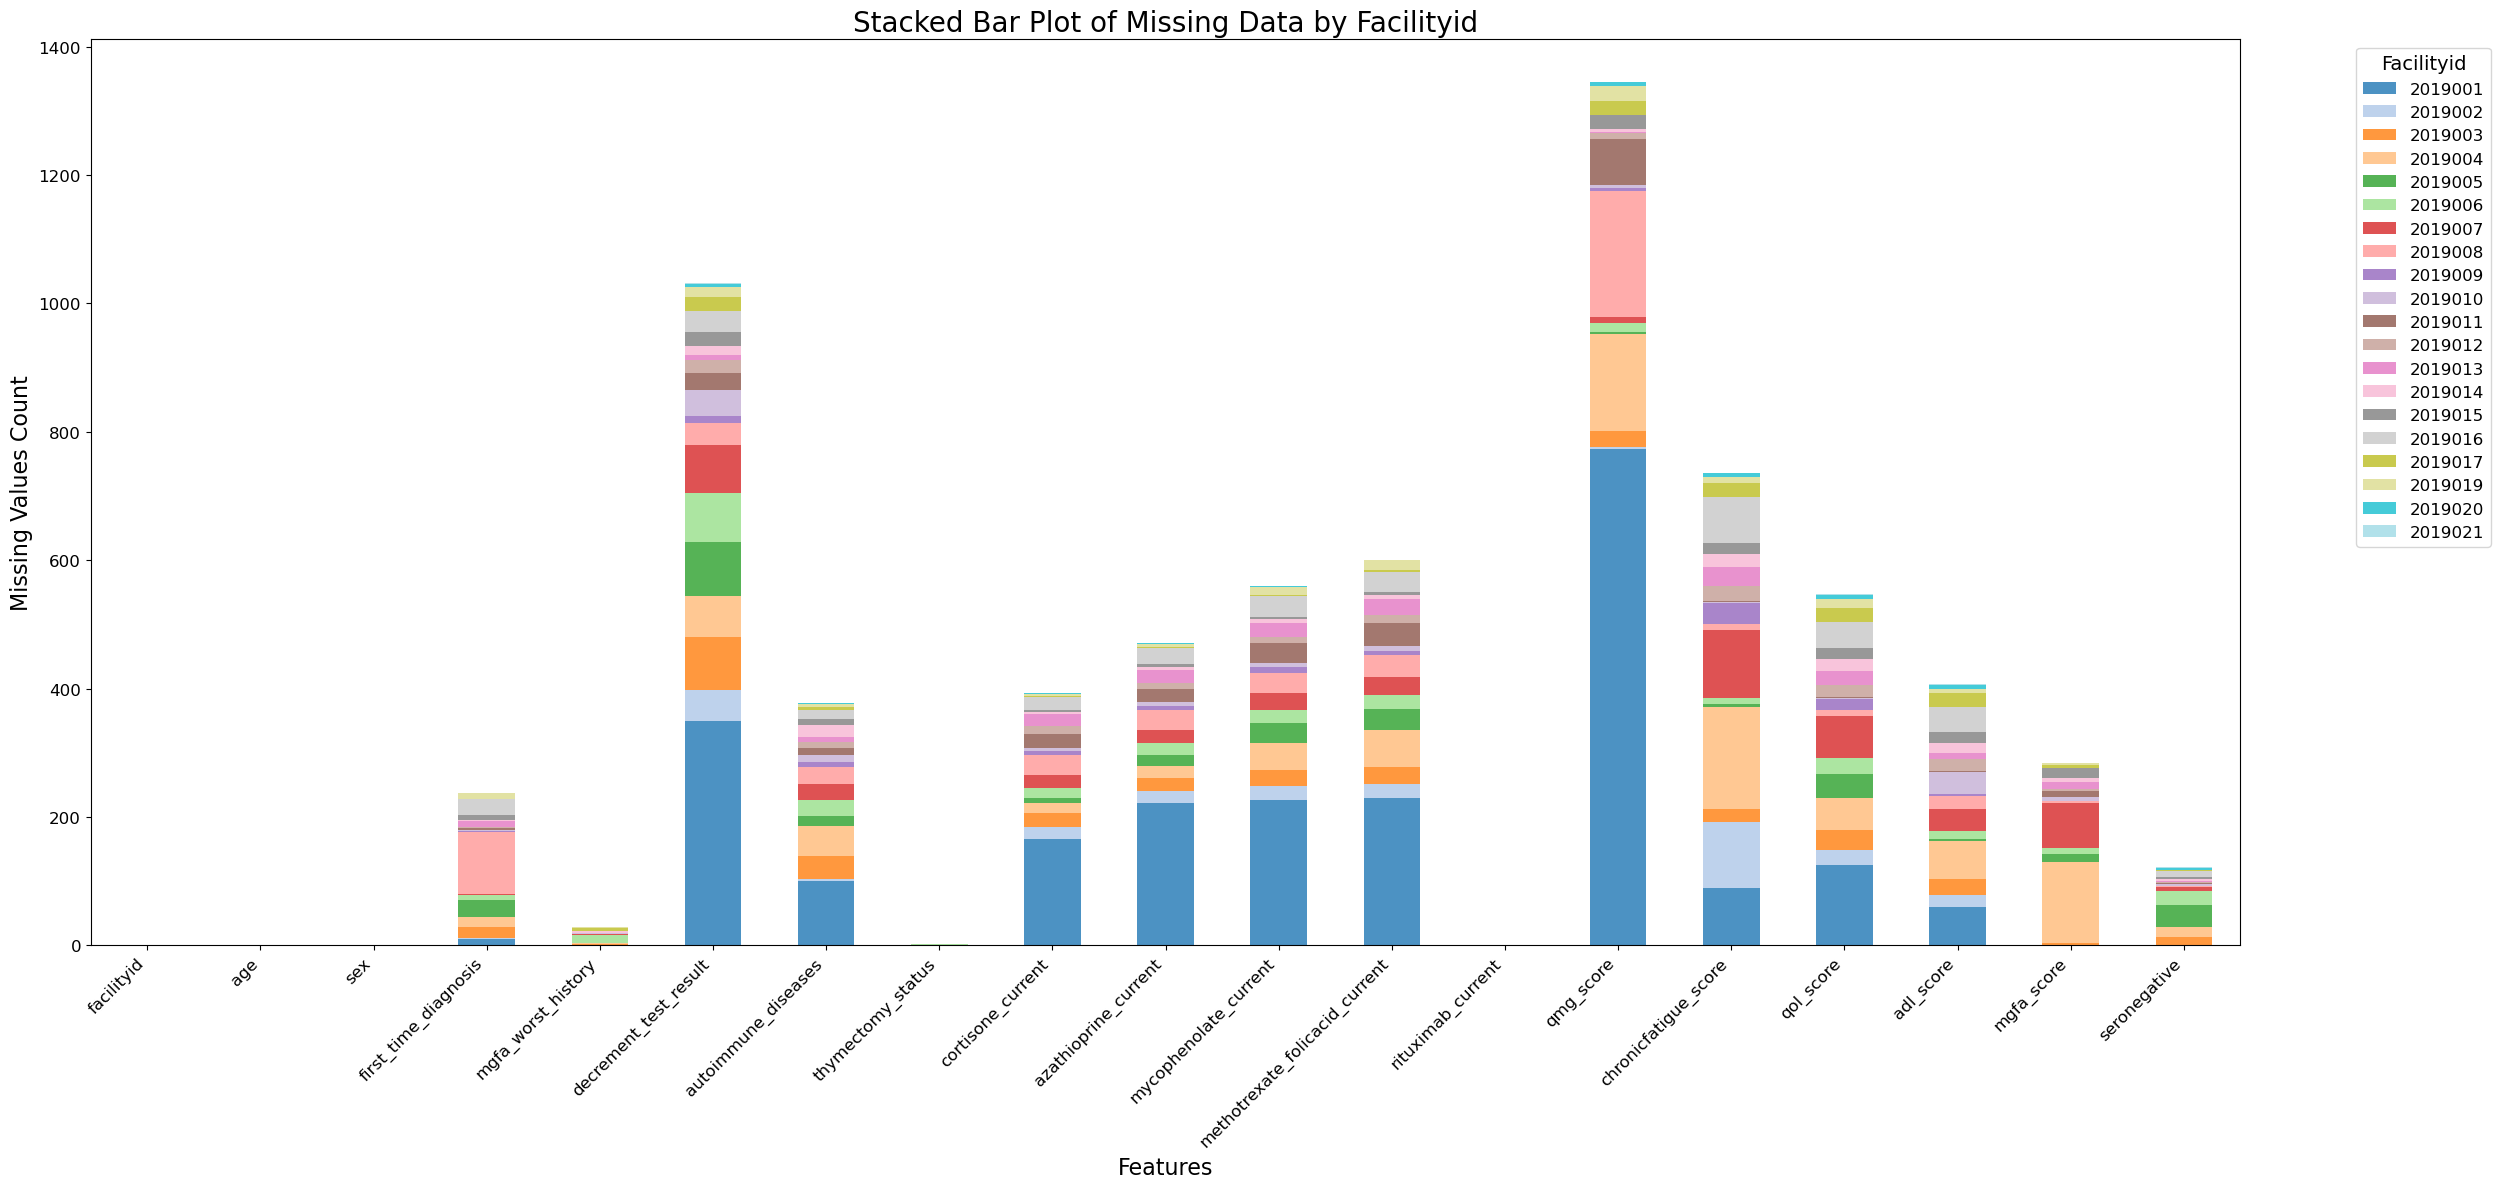

In [12]:
# Missing data count for each facilityid and feature
missing_counts = df_original.isnull().groupby(df_original['facilityid']).sum()

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(25, 12))

missing_counts.T.plot(kind='bar', stacked=True, ax=ax, cmap="tab20", alpha=0.8)

# Label the plot
plt.title('Stacked Bar Plot of Missing Data by Facilityid', fontsize=20)
plt.xlabel('Features', fontsize=16)
plt.ylabel('Missing Values Count', fontsize=16)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.legend(title='Facilityid', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.show()